<a href="https://colab.research.google.com/github/mahmudscode/NLP_work/blob/main/NLP_WORK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout,
    Bidirectional,
    LSTM
)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


## 1. Introduction

This section should introduce the problem of Bangla document classification, its importance, challenges specific to the Bengali language, and why explainability in deep learning models is crucial for this task. Briefly mention existing approaches and clearly state the contributions of your research. This will set the context for your conference paper.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

# Define the target path
target_path = '/content/drive/MyDrive/LLM_BANGLA_DATA/Bangla_newspaper'

# Change the current working directory
os.chdir(target_path)

# Verify the current working directory
print(f"Current working directory: {os.getcwd()}")

Current working directory: /content/drive/MyDrive/LLM_BANGLA_DATA/Bangla_newspaper


In [4]:
import os

for file in os.listdir():
    print(file)

data
data_v2
best_attention_model.keras
attention_bilstm_model_architecture.png


In [5]:
import os

for root, dirs, files in os.walk("data_v2"):
    print(f"\nFolder: {root}")
    print("Files:", files[:5])
    break


Folder: data_v2
Files: ['data_v2.json']


In [6]:
import os

for root, dirs, files in os.walk("data_v2"):
    if len(files) > 0:
        print("Example file:", os.path.join(root, files[0]))
        break

Example file: data_v2/data_v2.json


In [7]:
import json

with open("data_v2/data_v2.json", "r", encoding="utf-8") as f:
    data = json.load(f)

print(type(data))

<class 'list'>


In [8]:
print(len(data))

408471


In [9]:
data[0]

{'author': 'গাজীপুর প্রতিনিধি',
 'category': 'bangladesh',
 'category_bn': 'বাংলাদেশ',
 'published_date': '০৪ জুলাই ২০১৩, ২৩:২৬',
 'modification_date': '০৪ জুলাই ২০১৩, ২৩:২৭',
 'tag': ['গাজীপুর'],
 'comment_count': 0,
 'title': 'কালিয়াকৈরে টিফিন খেয়ে ৫০০ শ্রমিক অসুস্থ, বিক্ষোভ',
 'url': 'http://www.prothom-alo.com/bangladesh/article/19030',
 'content': 'গাজীপুরের কালিয়াকৈর উপজেলার তেলিরচালা এলাকায় আজ বৃহস্পতিবার রাতের টিফিন খেয়ে একটি পোশাক কারখানার ৫০০ শ্রমিক অসুস্থ হয়ে পড়েছেন। এ ঘটনায় বিক্ষোভ করেছেন ওই কারখানার শ্রমিকেরা।সফিপুর মডার্ন হাসপাতালের জরুরি বিভাগের চিকিত্সক আল আমিন প্রথম আলো ডটকমকে বলেন, খাদ্যে বিষক্রিয়ায় তাঁরা (শ্রমিকেরা) অসুস্থ হয়ে পড়েছেন। এতে আতঙ্কিত হওয়ার কিছু নেই। অসুস্থদের চিকিত্সা দেওয়া হয়েছে।কারখানার শ্রমিক ও পুলিশ সূত্রে জানা যায়, উপজেলার তেলিরচালা এলাকার সেজাদ সোয়েটার লিমিটেড কারখানার শ্রমিকদের আজ রাত সাড়ে সাতটার দিকে টিফিন দেওয়া হয়। টিফিনে ছিল ডিম, রুটি, পেটিস ও কলা। টিফিন খেয়ে শ্রমিকেরা যথারীতি কাজে যোগ দেন। ওই টিফিন খাওয়ার প্রায় এক ঘণ্টা 

In [10]:
import json
import pandas as pd

# The 'data' variable is already loaded from a previous cell (AU95EJfGjG5-).
# No need to open the file again or define a generator that reloads it.

# Take only sample first (VERY IMPORTANT for Colab)
sample_size = 100000

records = []
# Iterate directly over the 'data' list loaded from a previous cell
for i, item in enumerate(data):
    records.append({
        "text": str(item.get("title", "")) + " " + str(item.get("content", "")),
        "category": item.get("category", "")
    })

    if i + 1 >= sample_size:
        break

df = pd.DataFrame(records)

print(df.shape)
df.head()

(100000, 2)


,text,category
0,"কালিয়াকৈরে টিফিন খেয়ে ৫০০ শ্রমিক অসুস্থ, বিক...",bangladesh
1,সেমিফাইনাল বাধাও পেরিয়ে গেলেন লিসিকি এবারের উ...,sports
2,সংসদে খালেদার অভিযোগের জবাব দিয়েছে ভারত জাতীয...,bangladesh
3,পাসওয়ার্ড ভুলে যান! সহজ পাসওয়ার্ডের কারণে অন...,technology
4,চলে গেলেন মাউস উদ্ভাবক কম্পিউটার মাউসের উদ্ভাব...,technology


## 2. Dataset and Preprocessing

Provide a detailed description of the dataset used, including its source, size, and the types of documents it contains. Explain the initial observations from `df.head()` and `df.shape`. Discuss the preprocessing steps applied, such as `clean_text`, and justify why these specific steps (e.g., removing URLs, non-Bengali characters, extra spaces) are necessary for preparing Bangla text data for classification. It would also be beneficial to include a visualization of the class distribution to show if the dataset is balanced or imbalanced.

### Visualize Class Distribution

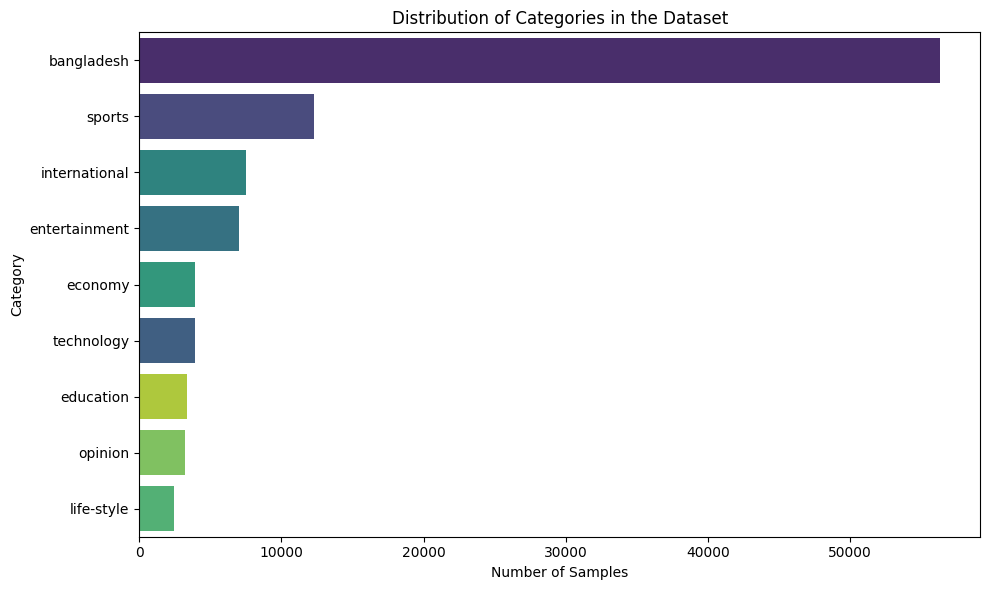

In [11]:
# Plot class distribution
plt.figure(figsize=(10, 6))
sns.countplot(y='category', data=df, order=df['category'].value_counts().index, palette='viridis', hue='category', legend=False)
plt.title('Distribution of Categories in the Dataset')
plt.xlabel('Number of Samples')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

# @title step_artifacts
num_fig = "1" # @param {type:"string"}
step = 'DatasetAndPreprocessing'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# Make sure to define `upload_plt_to_gcs` function or remove this line if not used
# upload_plt_to_gcs(num_fig, step, plt)

In [12]:
import re

def clean_text(text):
    text = str(text)

    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"www\S+", "", text)

    text = re.sub(r"[^\u0980-\u09FF\s]", " ", text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()

df["clean_text"] = df["text"].apply(clean_text)

In [13]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["label"] = encoder.fit_transform(df["category"])

print(dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))

{'bangladesh': np.int64(0), 'economy': np.int64(1), 'education': np.int64(2), 'entertainment': np.int64(3), 'international': np.int64(4), 'life-style': np.int64(5), 'opinion': np.int64(6), 'sports': np.int64(7), 'technology': np.int64(8)}


## 3. Model Architectures and Training

This section should detail the neural network architectures you've employed: CNN, BiLSTM, and the Attention-BiLSTM model. For each model, briefly explain its key components and why it's suitable for text classification. Justify the chosen hyperparameters such as `MAX_WORDS` for the tokenizer, `MAX_LEN` for padding, and batch sizes. Explain the purpose of `EarlyStopping`, `ReduceLROnPlateau`, and `ModelCheckpoint` callbacks in the training process.

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["label"],
    test_size=0.15,
    random_state=42,
    stratify=df["label"]
)

In [15]:
from tensorflow.keras.preprocessing.text import Tokenizer

MAX_WORDS = 50000

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

In [16]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 400

# Convert text to sequences using the tokenizer
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

print(X_train_pad.shape)

(85000, 400)


In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *

cnn_model = Sequential([
    Embedding(MAX_WORDS, 128, input_length=MAX_LEN),

    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),

    Dense(64, activation='relu'),
    Dropout(0.5),

    Dense(len(encoder.classes_), activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
cnn_history = cnn_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.1,
    epochs=5,
    batch_size=128
)

Epoch 1/5
598/598 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.8143 - loss: 0.6289 - val_accuracy: 0.9240 - val_loss: 0.2499
Epoch 2/5
598/598 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9405 - loss: 0.2066 - val_accuracy: 0.9338 - val_loss: 0.2210
Epoch 3/5
598/598 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9710 - loss: 0.0999 - val_accuracy: 0.9373 - val_loss: 0.2317
Epoch 4/5
598/598 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9867 - loss: 0.0476 - val_accuracy: 0.9381 - val_loss: 0.2686
Epoch 5/5
598/598 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9927 - loss: 0.0268 - val_accuracy: 0.9385 - val_loss: 0.3219


In [19]:
bilstm_model = Sequential([
    Embedding(MAX_WORDS, 128, input_length=MAX_LEN),

    Bidirectional(LSTM(64, dropout=0.3)),

    Dense(64, activation='relu'),
    Dropout(0.5),

    Dense(len(encoder.classes_), activation='softmax')
])

bilstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
bilstm_history = bilstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.1,
    epochs=5,
    batch_size=64
)

Epoch 1/5
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 53s 37ms/step - accuracy: 0.8141 - loss: 0.6214 - val_accuracy: 0.8984 - val_loss: 0.3392
Epoch 2/5
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 44s 37ms/step - accuracy: 0.9266 - loss: 0.2599 - val_accuracy: 0.9169 - val_loss: 0.2827
Epoch 3/5
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 45s 38ms/step - accuracy: 0.9577 - loss: 0.1512 - val_accuracy: 0.9268 - val_loss: 0.2883
Epoch 4/5
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 44s 37ms/step - accuracy: 0.9733 - loss: 0.0969 - val_accuracy: 0.9187 - val_loss: 0.3213
Epoch 5/5
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 44s 37ms/step - accuracy: 0.9797 - loss: 0.0713 - val_accuracy: 0.9166 - val_loss: 0.4083


In [21]:
import tensorflow as tf

from tensorflow.keras.layers import (
    Input,
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout,
    GlobalAveragePooling1D,
    Attention
)

from tensorflow.keras.models import Model

In [22]:
inputs = Input(shape=(MAX_LEN,))

embedding = Embedding(
    input_dim=MAX_WORDS,
    output_dim=128
)(inputs)

bilstm = Bidirectional(
    LSTM(
        64,
        return_sequences=True,
        dropout=0.3
    )
)(embedding)

attention = Attention()(
    [bilstm, bilstm]
)

pool = GlobalAveragePooling1D()(attention)

dense = Dense(
    64,
    activation='relu'
)(pool)

drop = Dropout(0.5)(dense)

outputs = Dense(
    len(encoder.classes_),
    activation='softmax'
)(drop)

attention_model = Model(
    inputs=inputs,
    outputs=outputs
)

attention_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 400)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 400, 128)  │  6,400,000 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 400, 128)  │     98,816 │ embedding_2[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 400, 128)  │          0 │ bidirectional_1[… │
│ (Attention)         │                   │            │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ attention[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 9)         │        585 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,507,657 (24.82 MB)

 Trainable params: 6,507,657 (24.82 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
attention_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Attention-BiLSTM Model Architecture

To visually represent the Attention-BiLSTM model, we can generate a diagram that shows its layers and their connections. This diagram is essential for the 'Model Architectures and Training' section of your paper, allowing readers to quickly grasp the structural details of your proposed model.

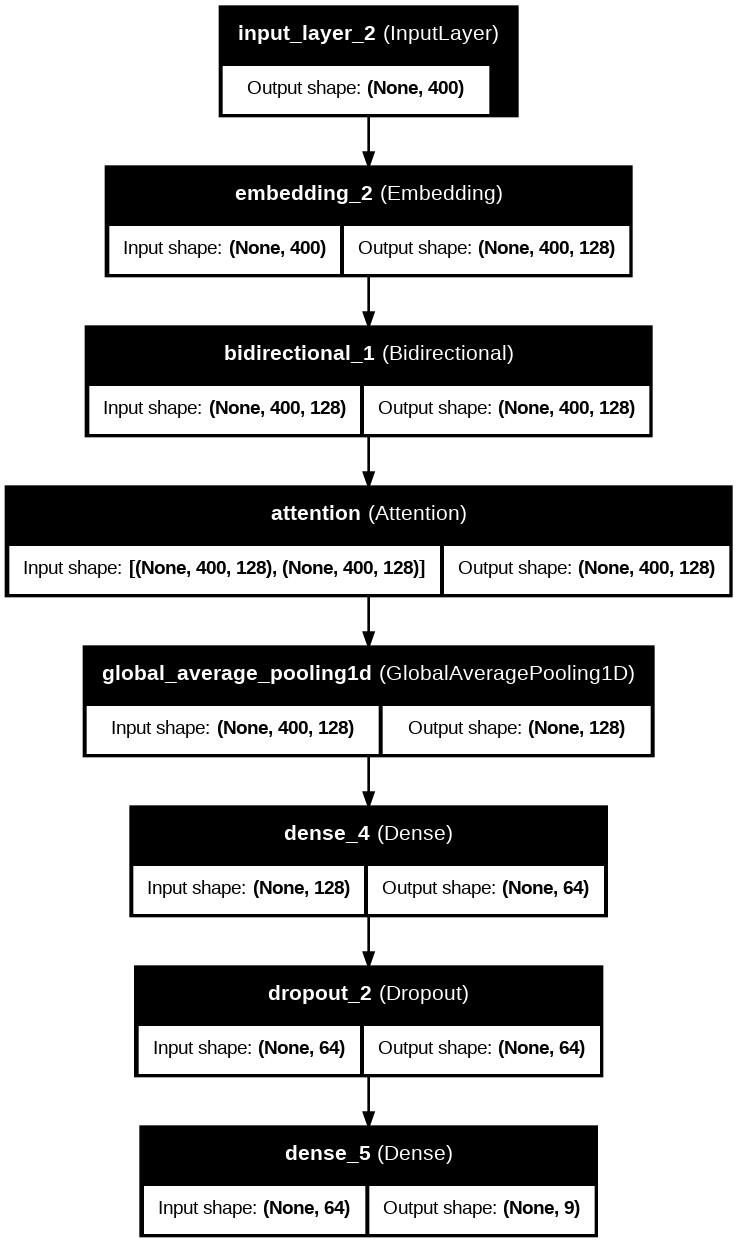

In [24]:
import tensorflow as tf

# Plot the Attention-BiLSTM model architecture
tf.keras.utils.plot_model(
    attention_model,
    to_file='attention_bilstm_model_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    dpi=96
)

# Display the image
from IPython.display import Image
Image(filename='attention_bilstm_model_architecture.png')


You might also consider adding similar architectural diagrams for your CNN and BiLSTM models if you plan to discuss them in detail in your methodology. This will provide a complete visual overview of all models developed.

In [25]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2
    ),

    ModelCheckpoint(
        "best_attention_model.keras",
        save_best_only=True
    )
]

In [26]:
history = attention_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=64,
    callbacks=callbacks
)

Epoch 1/15
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 61s 49ms/step - accuracy: 0.8034 - loss: 0.6362 - val_accuracy: 0.9224 - val_loss: 0.2615 - learning_rate: 0.0010
Epoch 2/15
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 55s 46ms/step - accuracy: 0.9445 - loss: 0.2014 - val_accuracy: 0.9361 - val_loss: 0.2165 - learning_rate: 0.0010
Epoch 3/15
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 80s 45ms/step - accuracy: 0.9700 - loss: 0.1072 - val_accuracy: 0.9405 - val_loss: 0.2376 - learning_rate: 0.0010
Epoch 4/15
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 53s 44ms/step - accuracy: 0.9822 - loss: 0.0635 - val_accuracy: 0.9333 - val_loss: 0.2669 - learning_rate: 0.0010
Epoch 5/15
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 53s 44ms/step - accuracy: 0.9919 - loss: 0.0308 - val_accuracy: 0.9398 - val_loss: 0.3321 - learning_rate: 5.0000e-04


In [27]:
loss, accuracy = attention_model.evaluate(
    X_test_pad,
    y_test,
    verbose=1
)

print(f"Test Accuracy: {accuracy:.4f}")

469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9406 - loss: 0.1933
Test Accuracy: 0.9406


In [28]:
predictions = attention_model.predict(
    X_test_pad
)

y_pred = predictions.argmax(axis=1)

469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step


In [29]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)

               precision    recall  f1-score   support

   bangladesh       0.97      0.96      0.97      8448
      economy       0.79      0.83      0.81       589
    education       0.90      0.91      0.91       498
entertainment       0.91      0.96      0.93      1053
international       0.94      0.89      0.92      1131
   life-style       0.79      0.85      0.82       368
      opinion       0.82      0.80      0.81       486
       sports       0.98      0.98      0.98      1840
   technology       0.87      0.89      0.88       587

     accuracy                           0.94     15000
    macro avg       0.89      0.90      0.89     15000
 weighted avg       0.94      0.94      0.94     15000



## 4. Results and Evaluation

Here, present and analyze the performance of all trained models (CNN, BiLSTM, Attention-BiLSTM). Discuss the validation accuracy obtained during training and the final test accuracy. Interpret the classification report, paying attention to precision, recall, and F1-score for each category. Explain what the confusion matrix reveals about the models' strengths and weaknesses, especially concerning misclassifications between similar categories. Conclude with a comparison of the models' overall performance, highlighting why the Attention-BiLSTM model, despite its complexity, might offer advantages or disadvantages over simpler models.

### Fixing Bangla Font Rendering in Plots

To ensure proper rendering of Bengali characters in your plots for a conference paper, you need to configure Matplotlib to use a font that supports Bengali glyphs. Here's how you can do it. This will address the `UserWarning: Glyph ... missing from font(s) DejaVu Sans.` messages.


In [30]:
# Install necessary font (e.g., Noto Sans Bengali)
# Use -qq to suppress output unless there's an error
!apt-get install -y -qq fonts-noto-extra

# Configure matplotlib to use the installed font
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# Clear Matplotlib's font cache and rebuild font list
# This is crucial after installing new fonts.
print("Clearing Matplotlib font cache and rebuilding font list...")
fm.fontManager = fm.FontManager() # Reinitialize font manager to rebuild cache
fm.findSystemFonts(fontpaths=None, fontext='ttf') # Re-scan for system fonts (explicitly call)

bengali_font_path = None
font_name = None

# Search for Noto Bengali fonts in the system fonts known to Matplotlib
found_noto_bengali = False
search_terms = ['noto', 'bengali'] # Look for fonts containing both terms

for font in fm.fontManager.ttflist:
    # Check if all search terms are in the font's name (case-insensitive)
    if all(term in font.name.lower() for term in search_terms):
        bengali_font_path = font.fname
        font_name = font.name
        found_noto_bengali = True
        break

if found_noto_bengali:
    # Set rcParams to use this font
    plt.rcParams['font.sans-serif'] = [font_name, 'DejaVu Sans', 'Arial'] # Prioritize Noto Bengali
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['axes.unicode_minus'] = False # Important for displaying '-' correctly with Unicode fonts

    print(f"Successfully configured Matplotlib to use font: {font_name} from {bengali_font_path}")
else:
    print("Could not find Noto Bengali font by explicit name in Matplotlib's font manager.")
    print("Listing all fonts containing 'noto' or 'bengali' to aid debugging:")
    found_any_bengali = False
    for font in fm.fontManager.ttflist:
        if any(term in font.name.lower() for term in search_terms):
            print(f"  Found: {font.name} (File: {font.fname})")
            found_any_bengali = True

    if not found_any_bengali:
        print("No fonts containing 'noto' or 'bengali' found in Matplotlib's font manager.")
        print("Please ensure 'fonts-noto-extra' is installed correctly and check font paths.")

    # Fallback to general sans-serif if specific Bengali font not found or identified
    print("Falling back to default sans-serif, which might not render Bengali characters correctly.")
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['axes.unicode_minus'] = False

# Re-run the confusion matrix plot or explanation plot after this cell to see the effect
# For example, if your confusion matrix plot was in cell BTjw_zacjoHb, re-execute that cell.
# The `explain_text` function in cell XrpnU5hSjpxv would also benefit from this.


Selecting previously unselected package fonts-noto-extra.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../fonts-noto-extra_20201225-1build1_all.deb ...
Unpacking fonts-noto-extra (20201225-1build1) ...
Setting up fonts-noto-extra (20201225-1build1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
Clearing Matplotlib font cache and rebuilding font list...
Successfully configured Matplotlib to use font: Noto Serif Bengali from /usr/share/fonts/truetype/noto/NotoSerifBengali-CondensedLight.ttf


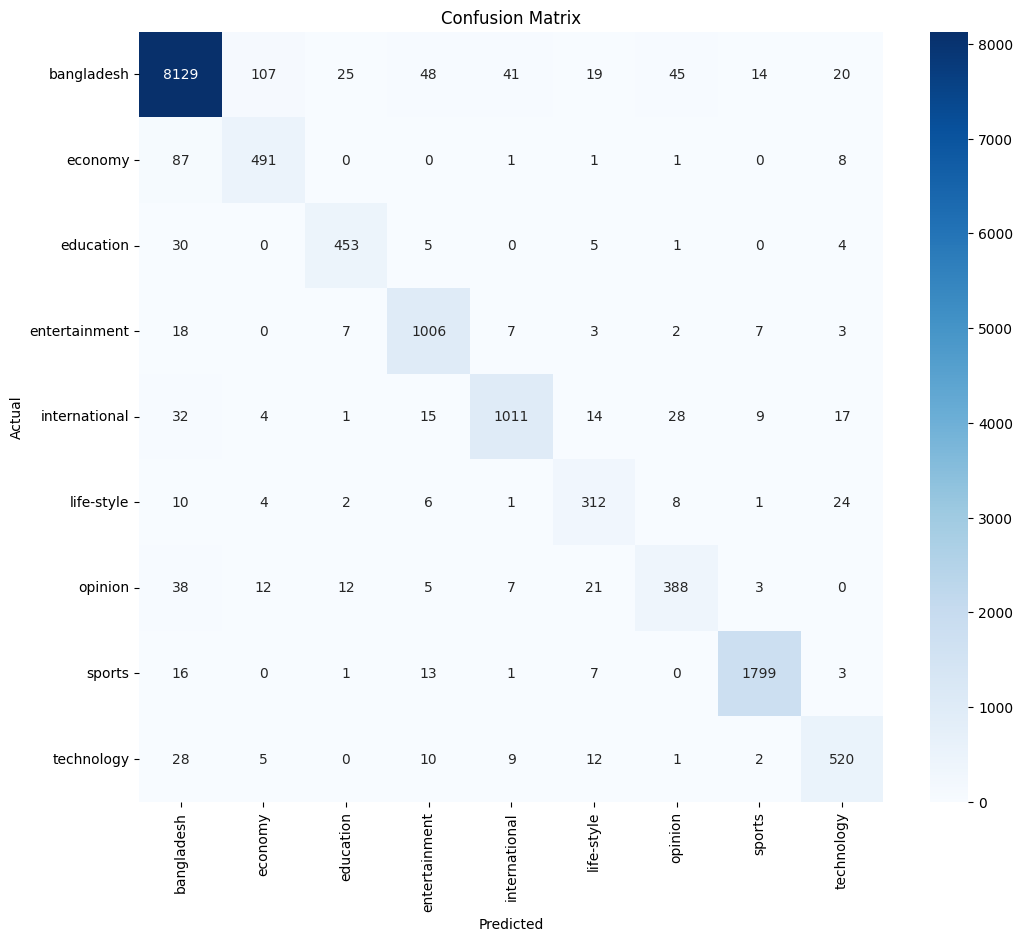

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Actual label: bangladesh
Predicted label: bangladesh
Confidence: 0.9990
Top contributing Bangla tokens:
উপজেলার: 1.0000
কর্তৃপক্ষের: 0.3342
ফটকে: 0.3050
উত্তোলন: 0.2874
খনি: 0.2683
খনি: 0.2317
শ্রমিক: 0.2256
ধর্মঘটের: 0.2208
শ্রমিকদের: 0.2167
সমাবেশ: 0.2162
মিছিল: 0.2145
পাথর: 0.2086
Using font from path: /usr/share/fonts/truetype/noto/NotoSerifBengali-CondensedLight.ttf


/tmp/ipykernel_326/2263048607.py:87: UserWarning: Glyph 108 (l) missing from font(s) Noto Serif Bengali.
  plt.tight_layout()
/tmp/ipykernel_326/2263048607.py:87: UserWarning: Glyph 112 (p) missing from font(s) Noto Serif Bengali.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 108 (l) missing from font(s) Noto Serif Bengali.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 112 (p) missing from font(s) Noto Serif Bengali.
  fig.canvas.print_figure(bytes_io, **kw)


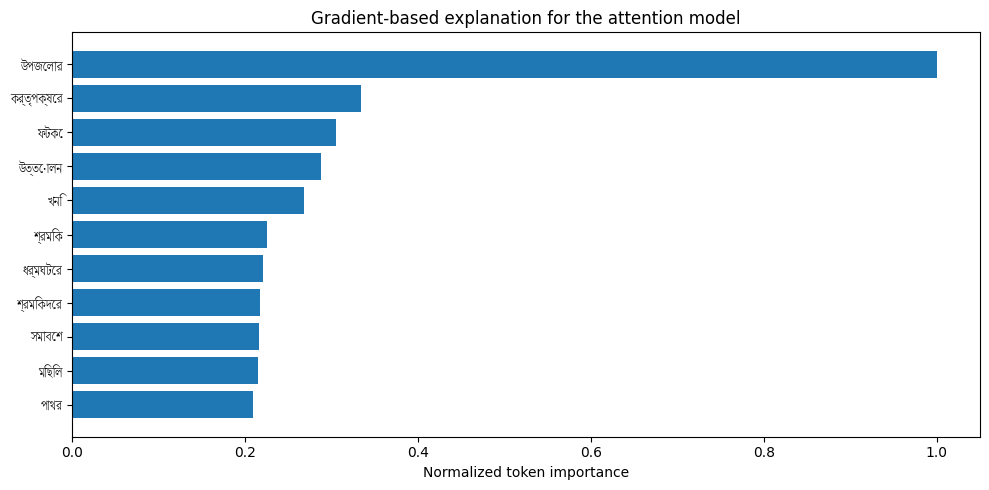

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import matplotlib.font_manager as fm # Import font_manager

reverse_word_index = {index: word for word, index in tokenizer.word_index.items()}

def explain_text(text, model=attention_model, top_k=12):
    cleaned_text = clean_text(text)
    sequence = tokenizer.texts_to_sequences([cleaned_text])
    padded = pad_sequences(sequence, maxlen=MAX_LEN, padding="post", truncating="post")
    input_tensor = tf.convert_to_tensor(padded)

    embedding_layer = model.layers[1]
    bilstm_layer = model.layers[2]
    attention_layer = model.layers[3]
    pool_layer = model.layers[4]
    dense_layer = model.layers[5]
    dropout_layer = model.layers[6]
    output_layer = model.layers[7]

    with tf.GradientTape() as tape:
        embeddings = embedding_layer(input_tensor)
        tape.watch(embeddings)
        sequence_output = bilstm_layer(embeddings, training=False)
        attention_output = attention_layer([sequence_output, sequence_output])
        pooled_output = pool_layer(attention_output)
        dense_output = dense_layer(pooled_output)
        dropout_output = dropout_layer(dense_output, training=False)
        probabilities = output_layer(dropout_output, training=False)
        predicted_class = tf.argmax(probabilities[0])
        class_score = probabilities[:, predicted_class]

    gradients = tape.gradient(class_score, embeddings)[0]
    token_scores = tf.reduce_sum(tf.abs(gradients) * tf.abs(embeddings[0]), axis=-1).numpy()

    tokens = [reverse_word_index.get(int(token_id), "") for token_id in padded[0] if int(token_id) != 0]
    token_scores = token_scores[:len(tokens)]

    valid_tokens = []
    valid_scores = []
    for token, score in zip(tokens, token_scores):
        if token.strip():
            valid_tokens.append(token)
            valid_scores.append(float(score))

    if not valid_tokens:
        print("No explainable tokens found for this sample.")
        return

    scores = np.array(valid_scores, dtype=float)
    if scores.max() > 0:
        scores = scores / scores.max()

    top_indices = np.argsort(scores)[-min(top_k, len(scores)):]
    top_tokens = [valid_tokens[i] for i in top_indices]
    top_scores = scores[top_indices]

    predicted_label = encoder.inverse_transform([int(predicted_class.numpy())])[0]
    predicted_probability = float(tf.reduce_max(probabilities).numpy())

    print(f"Predicted label: {predicted_label}")
    print(f"Confidence: {predicted_probability:.4f}")
    print("Top contributing Bangla tokens:")

    ranked = sorted(zip(top_tokens, top_scores), key=lambda item: item[1], reverse=True)
    for token, score in ranked:
        print(f"{token}: {score:.4f}")

    plt.figure(figsize=(10, 5))

    # Use the globally available bengali_font_path to directly load the font
    if 'bengali_font_path' in globals() and bengali_font_path is not None:
        bengali_font_prop = fm.FontProperties(fname=bengali_font_path)
        print(f"Using font from path: {bengali_font_path}")
    else:
        print("Warning: Bengali font path not found. Falling back to default sans-serif.")
        bengali_font_prop = fm.FontProperties(family='sans-serif')

    ordered_indices = np.argsort(top_scores)
    plt.barh(np.array(top_tokens)[ordered_indices], top_scores[ordered_indices], color="#1f77b4")
    # Apply Bengali font only to y-axis labels (tokens)
    plt.yticks(fontproperties=bengali_font_prop) # Apply font to y-axis ticks (labels)
    # Allow Matplotlib to use its default font for English labels
    plt.xlabel("Normalized token importance")
    plt.title("Gradient-based explanation for the attention model")
    plt.tight_layout()
    plt.show()

sample_index = 0
sample_text = X_test.iloc[sample_index]
print("Actual label:", encoder.inverse_transform([int(y_test.iloc[sample_index])])[0])
explain_text(sample_text)


## 5. Explainability Analysis

This section is crucial for the 'Explainable' aspect of your research. Describe the gradient-based explanation method implemented in your `explain_text` function. Explain what the 'Normalized token importance' represents and how it helps in understanding the model's decision-making process for specific predictions. Analyze the example provided by `explain_text`, discussing whether the identified top contributing Bangla tokens intuitively align with the predicted category. Provide insights into how this explainability can be useful for debugging the model, gaining trust, or understanding linguistic patterns.


In [34]:
attention_model.save(
    "/content/drive/MyDrive/attention_bilstm_bangla.keras"
)

In [35]:
import pickle

with open(
    "/content/drive/MyDrive/tokenizer.pkl",
    "wb"
) as f:

    pickle.dump(
        tokenizer,
        f
    )

### Another XAI Example

Let's examine another sample from the test set to see how the model makes predictions for a different category and what tokens contribute most to that decision.

Actual label: bangladesh
Predicted label: bangladesh
Confidence: 0.9986
Top contributing Bangla tokens:
মতিউর: 1.0000
জেনারেল: 0.9475
সেক্রেটারি: 0.8708
নির্বাচন: 0.8296
মুজাহিদ: 0.7940
রিটের: 0.7756
আহসান: 0.7362
পাঠানোর: 0.6954
কমিশনসহ: 0.6514
রহমান: 0.6455
আলী: 0.6352
জানতে: 0.6274
Using font from path: /usr/share/fonts/truetype/noto/NotoSerifBengali-CondensedLight.ttf


/tmp/ipykernel_326/2263048607.py:87: UserWarning: Glyph 108 (l) missing from font(s) Noto Serif Bengali.
  plt.tight_layout()
/tmp/ipykernel_326/2263048607.py:87: UserWarning: Glyph 112 (p) missing from font(s) Noto Serif Bengali.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 108 (l) missing from font(s) Noto Serif Bengali.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 112 (p) missing from font(s) Noto Serif Bengali.
  fig.canvas.print_figure(bytes_io, **kw)


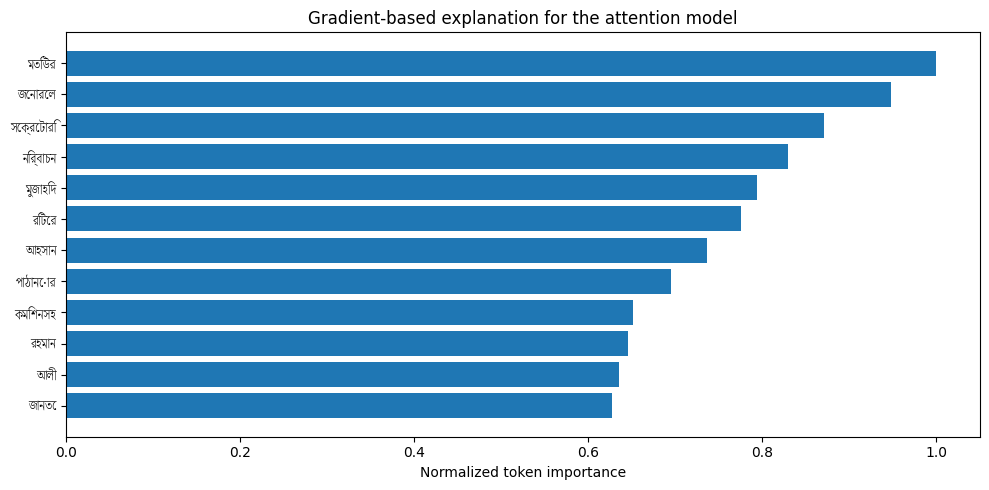

In [36]:
sample_index_2 = 1
sample_text_2 = X_test.iloc[sample_index_2]
print("Actual label:", encoder.inverse_transform([int(y_test.iloc[sample_index_2])])[0])
explain_text(sample_text_2)

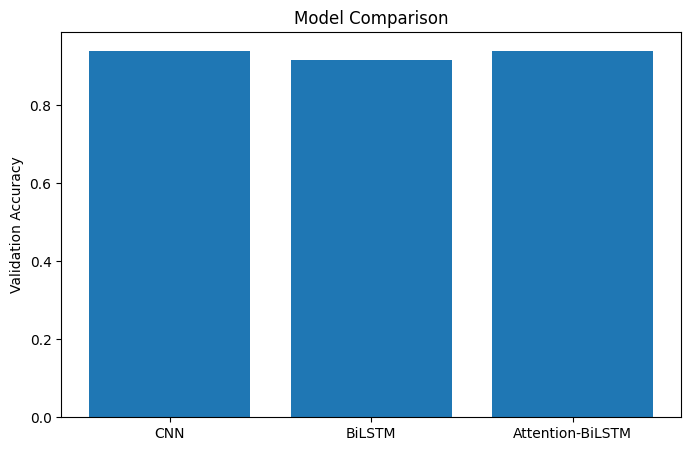

In [33]:
models = [
    "CNN",
    "BiLSTM",
    "Attention-BiLSTM"
]

accuracies = [
    cnn_history.history['val_accuracy'][-1],
    bilstm_model.history.history['val_accuracy'][-1] if hasattr(bilstm_model, 'history') else 0,
    history.history['val_accuracy'][-1]
]

plt.figure(figsize=(8,5))

plt.bar(
    models,
    accuracies
)

plt.title("Model Comparison")
plt.ylabel("Validation Accuracy")

plt.show()

## 6. Conclusion, Limitations, and Future Work

Conclude your paper by summarizing the main findings and contributions. Discuss the limitations of your current approach, such as potential biases in the dataset, computational constraints, or specific challenges in Bangla text processing that were not fully addressed. Finally, propose clear directions for future work, which could include exploring more advanced attention mechanisms, incorporating external linguistic resources, testing with larger or more diverse Bangla datasets, or deploying the model in real-world applications.